# ***PRAKTIKUM 11 MACHINE LEARNING ALGORITMA KMEANS***
## **DATASET IRIS**

### 1. Import Library

In [3]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### 2. Load Dataset

In [4]:
# load Dataset
df = pd.read_csv('../data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 3. Eksplorasi Data

In [5]:
# melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
# cek missing value
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

#### Cek Variasi Spesiesnya

In [7]:
# melihat dsitribusi kelas pada kolom 'Spesies'
sns.countplot(data=df, x='Species')
plt.tittle('Distribusi Kelas pada Spesies')
plt.show()

AttributeError: module 'numpy' has no attribute 'countplot'

### 4. Pemilihan Fitur

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['SpeciesEncoded'] = le.fit_transform(df['Species'])

In [8]:
# fitur untuk clustering
X = df.drop(["Id", "Species", "SpeciesEncoded"], axis=1)

KeyError: "['SpeciesEncoded'] not found in axis"

### 5. Menentukan Jumlah Cluster (K) dengan Metode Elbow

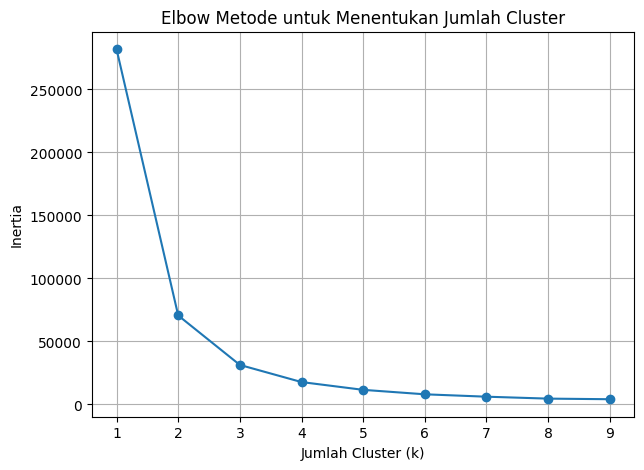

In [ ]:
from sklearn.cluster import KMeans

inertia_list = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_range, inertia_list, marker='o')
plt.title('Elbow Metode untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

### 6. Membangun Model KMeans

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

In [ ]:
df["Cluster"] = kmeans.fit_predict(X)
print("Cluster ditemukan: ", df["Cluster"].unique())

Cluster ditemukan:  [2 0 1]


### 7. Evaluasi Kualitas Clustering

In [ ]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X, df["Cluster"])
print("\n======= Silhouette Score =======")
print("Silhouette Score: ", sil_score)


======= Silhouette Score =======
Silhouette Score:  0.5816702617893469


### 8. Confussion Matrix (Perbandingan dengan Label Asli)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print("\n======= Confusion Matrix =======")
cm = confusion_matrix(df['SpeciesEncoded'], df['Cluster'])
print(cm)


======= Confusion Matrix =======
[[ 1  0 49]
 [49  1  0]
 [ 0 50  0]]


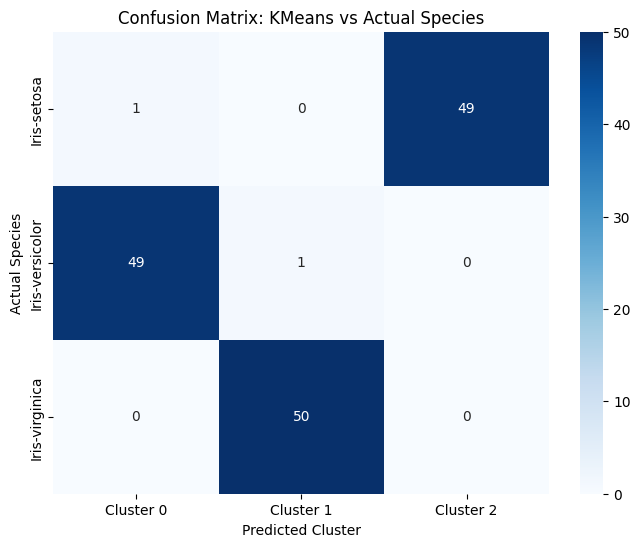

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=le.classes_)

plt.title("Confusion Matrix: KMeans vs Actual Species")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Species")
plt.show()

### 9. 2D dan 3D Visualisasi Hasil Model KMeans

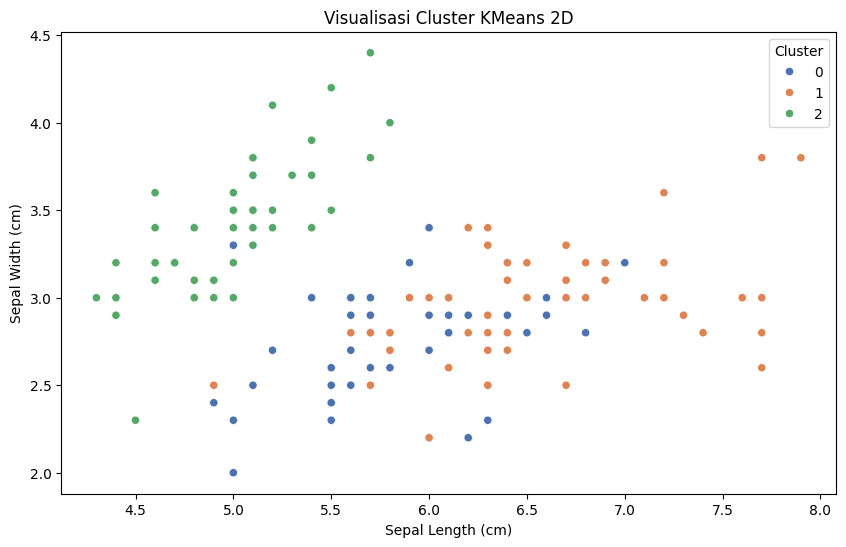

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['SepalLengthCm'],
    y=df['SepalWidthCm'],
    hue=df['Cluster'],
    palette="deep"
)

plt.title("Visualisasi Cluster KMeans 2D")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title='Cluster')
plt.show()

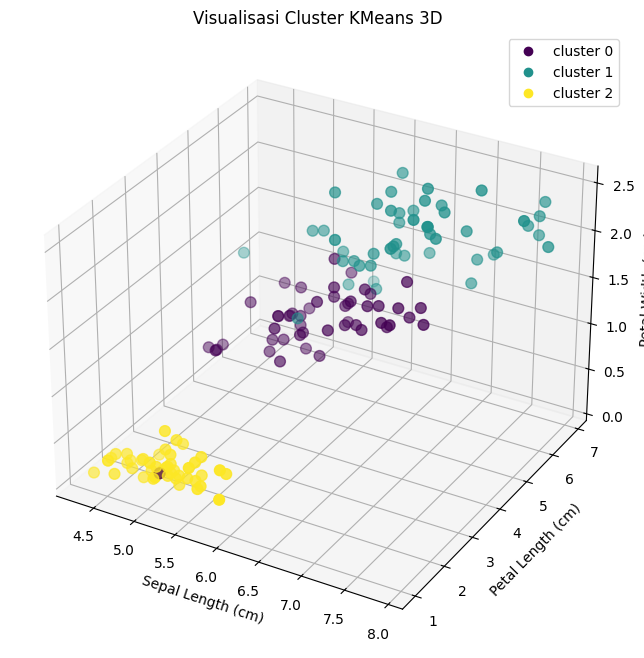

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['SepalLengthCm'],
    df['PetalLengthCm'],
    df['PetalWidthCm'],
    c=df['Cluster'],
    s=60
)

ax.set_title("Visualisasi Cluster KMeans 3D")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.set_zlabel("Petal Width (cm)")

legend_labels = [f"cluster {i}" for i in range(3)]
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)
plt.show()